## 第九章 聚类
聚类属于`无监督学习`的一种，其目标是通过没有标签的训练样本的学习来揭示数据的内在性质和规律。聚类既能作为一个单独的过程，用于寻找数据内在的分布结构，也可以作为分类等其他学习任务的前处理过程。简单来说，聚类就是使得“物以类聚，人以群分”的过程。   
### 9.1 性能度量
在聚类中，我们希望的最终结果是“簇内相似度高，簇间相似度低”，这一点有点类似LAD算法。衡量聚类的性能主要分为两大类：
- 外部指标：将聚类结果与某个参考模型进行比较，这一过程类似于监督学习中的性能评估。我们定义：   
$$
\begin{array}{l}
a=|S S|,\quad SS=\left\{\left(\boldsymbol{x}_{i},\boldsymbol{x}_{j}\right)\mid\lambda_{i}=\lambda_{j},\lambda_{i}^{*}=\lambda_{j}^{*}, i<j\right\},\\
b=|S D|,\quad SD=\left\{\left(\boldsymbol{x}_{i},\boldsymbol{x}_{j}\right)\mid\lambda_{i}=\lambda_{j},\lambda_{i}^{*}\neq\lambda_{j}^{*}, i<j\right\},\\
c=|D S|,\quad DS=\left\{\left(\boldsymbol{x}_{i},\boldsymbol{x}_{j}\right)\mid\lambda_{i}\neq\lambda_{j},\lambda_{i}^{*}=\lambda_{j}^{*}, i<j\right\},\\
d=|D D|,\quad DD=\left\{\left(\boldsymbol{x}_{i},\boldsymbol{x}_{j}\right)\mid\lambda_{i}\neq\lambda_{j},\lambda_{i}^{*}\neq\lambda_{j}^{*}, i<j\right\},
\end{array}
$$  
常用的外部指标有：
1. Jaccard系数:
 $$JC=\frac{a}{a+b+c}$$
2. FM指数：
$$\text{FMI} = \sqrt{\frac{a}{a + b} \cdot \frac{a}{a + c}}$$
3. Rand指数：
$$RI=\frac{2(a+b)}{m(m-1)}$$    

**上述指标结构均在[0,1]区间，值越大越好。**     
- 内部指标：直接考察聚类结果而不利用任何参考模型。     
对于簇内，我们定义：   
$$
\begin{aligned}
\operatorname{avg}(C) &= \frac{2}{|C|(|C|-1)} \sum_{1 \leqslant i < j \leqslant |C|} \operatorname{dist}\left(\boldsymbol{x}_{i}, \boldsymbol{x}_{j}\right), \\
\operatorname{diam}(C) &= \max_{1 \leqslant i < j \leqslant |C|} \operatorname{dist}\left(\boldsymbol{x}_{i}, \boldsymbol{x}_{j}\right),
\end{aligned}
$$
对于簇间，我们定义：   
$$
\begin{aligned}
d_{\min}(C_i, C_j) &= \min_{\boldsymbol{x}_i \in C_i, \boldsymbol{x}_j \in C_j} \operatorname{dist}(\boldsymbol{x}_i, \boldsymbol{x}_j), \\
d_{\text{cen}}(C_i, C_j) &= \operatorname{dist}(\boldsymbol{\mu}_i, \boldsymbol{\mu}_j),
\end{aligned}
$$
其中，$\boldsymbol{\mu}_i$表示簇$C_i$的中心，取均值。     
常用的内部指标有：
1. DB指数：
$$
\mathrm{DBI} = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i} \left( \frac{\operatorname{avg}(C_{i}) + \operatorname{avg}(C_{j})}{d_{\text{cen}}(\boldsymbol{\mu}_{i}, \boldsymbol{\mu}_{j})} \right)
$$
**越小越好**

2. Dunnn指数：
$$
\mathrm{DI} = \min_{1 \leqslant i \leqslant k} \left\{ \min_{j \neq i} \left( \frac{d_{\min}(C_i, C_j)}{\max_{1 \leqslant l \leqslant k} \operatorname{diam}(C_l)} \right) \right\}
$$
**越大越好**


### 9.2 距离计算
对于连续取值，我们常用`闵可夫斯基距离`
$$
\operatorname{dist}_{\mathrm{mk}}\left(\boldsymbol{x}_{i}, \boldsymbol{x}_{j}\right) = \left( \sum_{u=1}^{n} \left| x_{iu} - x_{ju} \right|^{p} \right)^{\frac{1}{p}}
$$
特别的，当$p=1$时，就是`曼哈顿距离`
$$
\operatorname{dist}_{\mathrm{manhattan}}\left(\boldsymbol{x}_{i}, \boldsymbol{x}_{j}\right) = \sum_{u=1}^{n} \left| x_{iu} - x_{ju} \right|
$$
当$p=2$时，就是`欧氏距离`
$$
\operatorname{dist}_{\mathrm{euclidean}}\left(\boldsymbol{x}_{i}, \boldsymbol{x}_{j}\right) = \sqrt{\sum_{u=1}^{n} \left( x_{iu} - x_{ju} \right)^{2}}
$$
当$p=\infty$时，就是`切比雪夫距离`，此时整体距离取决于距离最远的那两个点。
$$
\operatorname{dist}_{\mathrm{chebyshev}}\left(\boldsymbol{x}_{i}, \boldsymbol{x}_{j}\right) = \max_{u=1}^{n} \left| x_{iu} - x_{ju} \right|
$$
当$p=0$时，就是`hamming距离`，此时只有当两个向量的对应位置元素不同时，距离就加1，否则为0。
$$
\operatorname{dist}_{\mathrm{hamming}}\left(\boldsymbol{x}_{i}, \boldsymbol{x}_{j}\right) = \sum_{u=1}^{n} \left( x_{iu} \neq x_{ju} \right)
$$
对于离散且无序的取值，我们可以用之前的`one-hot编码`先对数据进行预处理。而针对聚类问题，可采用VDM：
$$
\operatorname{VDM}_{p}(a, b) = \sum_{i=1}^{k} \left| \frac{m_{u,a,i}}{m_{u,a}} - \frac{m_{u,b,i}}{m_{u,b}} \right|^{p} .
$$
其中$m_{u,a,i}$表示在第$i$个簇中属性$u$上取值为$a$的个数，$m_{u,a}$表示属性$u$取值为$a$的总个数。  
综上，我们结合闵可夫斯基距离和VDM，可以得到如下距离计算公式：   
$$
\operatorname{MinkovDM}_{p}\left(\boldsymbol{x}_{i}, \boldsymbol{x}_{j}\right) = \left( \sum_{u=1}^{n_{c}} \left| x_{iu} - x_{ju} \right|^{p} + \sum_{u=n_{c}+1}^{n} \operatorname{VDM}_{p}\left(x_{iu}, x_{ju}\right) \right)^{\frac{1}{p}} .
$$


### 9.3 原型聚类
原型是指样本空间中具有代表性的点，而原型聚类假设聚类结构可以通过一组原型刻画。
- `k均值算法(k-means)`    
k-means的划分目标是最小化：
$$
E = \sum_{i=1}^{k} \sum_{\boldsymbol{x} \in C_{i}} \left\| \boldsymbol{x} - \boldsymbol{\mu}_{i} \right\|_{2}^{2}
$$  
E刻画了簇内样本围绕簇均值的紧密程度，E值越小说明簇内相似度越高。   
结合EM算法，迭代优化来求得近似解。    
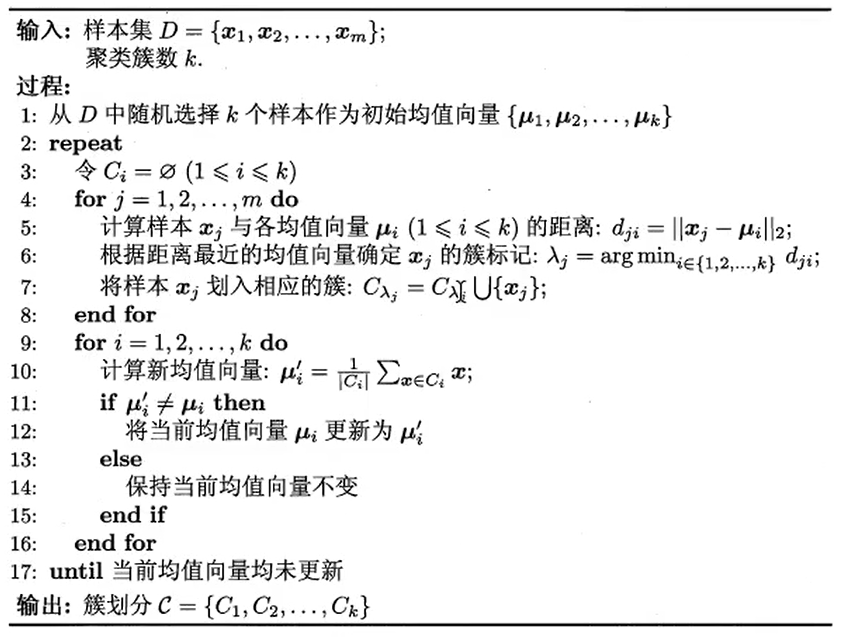

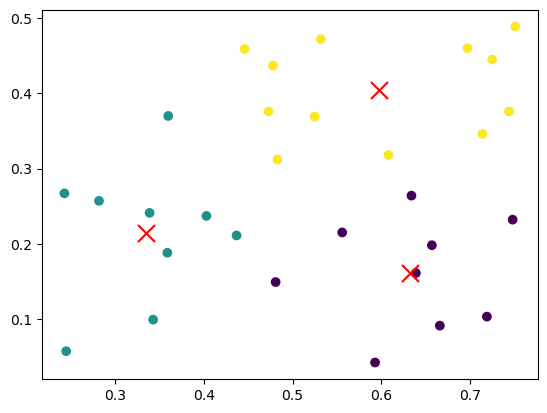

In [8]:
import numpy as np
import matplotlib.pyplot as plt

class KMeans:
    def __init__(self,k,max_iter = 10):
        """
        K-means聚类算法
        参数:
        k: 聚类簇数
        max_iter: 最大迭代次数
        """
        self.k = k
        self.max_iter = max_iter
        self.centroids  = None # 聚类中心
        self.labels = None # 聚类标签

    def calculate_distance(self,x,μ):
        """计算样本点与聚类中心之间的欧氏距离"""
        return np.sqrt(np.sum((x - μ)**2))
    
    def find_closest_centroid(self,distances):
        """返回最近的聚类中心索引"""
        return np.argmin(distances)
    
    def fit(self,data):
        """训练"""
        self.labels = np.zeros(len(data))
        # 随机选择K个样本点作为初始聚类中心
        # rand_index = np.random.choice(len(data),self.k,replace = False)
        rand_index = [5,11,23] # 与书上保持一样
        self.centroids = data[rand_index]
        # 迭代寻找最优解
        for i in range(self.max_iter):
            # E-step
            for j in range(len(data)):
                distances = []
                for k in range(self.k):
                    d = self.calculate_distance(data[j],self.centroids[k])
                    distances.append(d)
                # 找到最近的聚类中心
                closest_centroid = self.find_closest_centroid(distances)
                # 更新样本点的标签
                self.labels[j] = closest_centroid
            # M-step
            for j in range(self.k):
                # 更新聚类中心
                new_centroids = np.mean(data[self.labels == j],axis = 0)
                self.centroids[j] = new_centroids

if __name__ == '__main__':
    # 加载数据
    data = np.loadtxt('./Data/4.0.csv',dtype = float,delimiter = ',')
    # 实例化KMeans
    kmeans = KMeans(k = 3,max_iter = 4)
    # 训练
    kmeans.fit(data)
    # 可视化
    plt.scatter(data[:,0],data[:,1],c = kmeans.labels)
    plt.scatter(kmeans.centroids[:,0],kmeans.centroids[:,1],marker = 'x',s = 150,c = 'r')
    plt.show()

    




- `学习向量量化(LVQ)`   
LVQ试图找到一组**原型向量**来刻画聚类结构，且要求数据样本带有**标签**。    
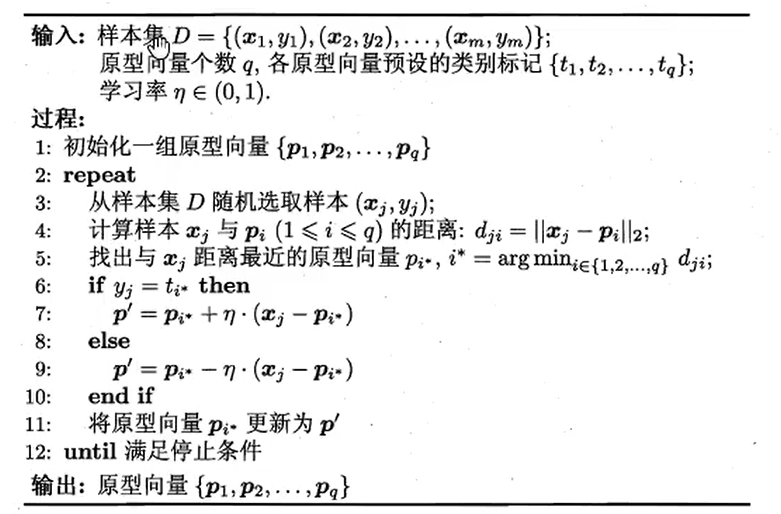    